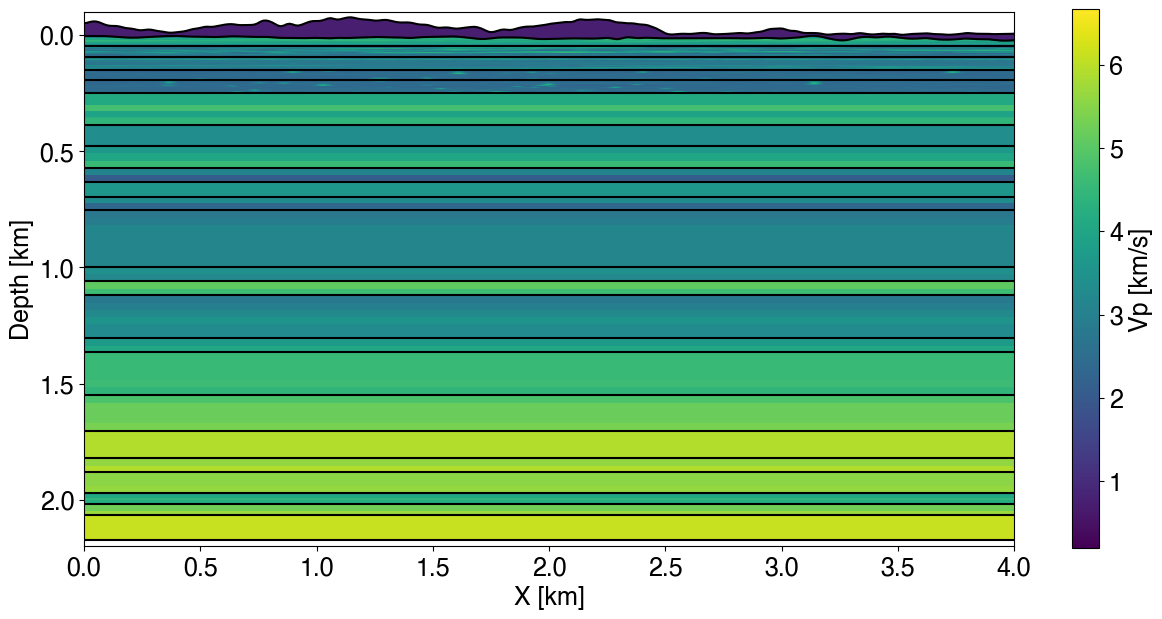

In [1]:
import xarray as xr
import numpy as np

from pathlib import Path

from frequensolve import *

project_path = "./scratch/ex_03/"
project = Project(name           = "project",
                  pretty_name    = "Desert Simulation",
                  path           = project_path,
                  load_if_exists = False)

sim = SeismicSimulation(name      = "desert",
                        physics   = "elastic",
                        dimension = 2)
project += sim

dpath = "/Users/jacobbadger/hp3D/LIBS/problems/desert_2d/"

# ----------------------------------------------------------------------
# Define Model
# ----------------------------------------------------------------------
model = LayeredModel(dimension = 2, x_limits = [0.0, 4.0])
model.add_surface(
   name = "dune_topo",
   xarr = CartesianGrid(n = [320], x0 = [0.0], x1 = [4.029]).as_xarray(),
   z    = Path(dpath) / "data/dunes.bin",
   z_ref = 0.0,
)
                  
model.add_layer(
   name = "sand",
   properties = { "Vp" : 0.731, "Vs" : 0.3, "Rho": 1.6 }
)
                
model.add_surface(
   name = "buried_topo",
   xarr = CartesianGrid(n = [1344], x0 = [0.0], dx = [3e-3]).as_xarray(),
   z    = Path(dpath) / "data/buried.bin",
   z_ref = 0.025,
   scale = 1000
)

model.add_layer(
   name = "near_surface",
   xarr = xr.DataArray(coords = {"x" : np.linspace(0.0, 4.0, 1344),
                                 "z" : np.linspace(0.0, 0.25, 210)},
                       dims = ["z", "x"]),
   properties = { "Vp" : Path(dpath) / "data/Vp_smooth.bin|1000",
                  "Vs" : Path(dpath) / "data/Vs_smooth.bin|1000",
                  "Rho": Path(dpath) / "data/Rho_smooth.bin"}
)
model.add_surface(z = 0.483e-1)
model.add_surface(z = 0.972e-1)
model.add_surface(z = 1.512e-1)
model.add_surface(z = 1.941e-1)
model.add_surface(z = 2.508e-1)

model.add_layer(
   name = "near_surface",
   xarr = xr.DataArray(coords = {"x" : np.linspace(0.0, 4.0, 1344),
                                 "z" : np.linspace(0.0, 2.175, 7250)},
                       dims = ["z", "x"]),
   properties = { "Vp" : Path(dpath) / "data/Vp.bin|1000",
                  "Vs" : Path(dpath) / "data/Vs.bin|1000",
                  "Rho": Path(dpath) / "data/Rho.bin"}
)

z_list_full = [ 3.012e-1, 3.3e-1, 3.9e-1, 4.791e-1, 5.091e-1, 5.412e-1, 
               5.712e-1, 6.03e-1, 6.312e-1, 6.99e-1, 7.242e-1, 
               7.551e-1, 7.83e-1, 8.16e-1, 9.981e-1, 1.0272e0, 
               1.059e0, 1.0941e0, 1.1211e0, 1.1532e0, 1.182e0,
               1.2111e0, 1.2411e0, 1.3032e0, 1.335e0, 1.3662e0, 
               1.548e0, 1.581e0, 1.7052e0, 1.8201e0, 1.851e0,
               1.881e0, 1.9692e0, 1.989e0, 2.016e0, 2.0451e0, 
               2.067e0, 2.175e0 ]

z_list = [ 3.9e-1, 4.791e-1, 5.712e-1, 6.312e-1, 6.99e-1, 
          7.551e-1, 9.981e-1, 1.059e0, 1.1211e0, 1.3032e0, 1.3662e0, 
          1.548e0, 1.7052e0, 1.8201e0, 1.881e0, 1.9692e0, 2.016e0,
          2.067e0, 2.175e0 ]

for z in z_list:
    model.add_surface(z = z)
model.plot("Vp",resolution=[1000,1000],figsize=(15,7),fontsize=18,aspect="equal")


In [2]:

sim.model = model


mesh = model.hex_mesh_generator(n = [4, 4])
sim += mesh


# New boundery condition manager
BCs = BoundaryConditionManager(label_type = "geometric")

# Free surface BC
BCs += BoundaryCondition(name       = "free_surface",
                             kind       = "neumann",
                             boundaries = ["z_min"])

# PML boundary condition
BCs += BoundaryCondition(name = "pml",
                             kind = "pml",
                             boundaries = ["x_min", "x_max", "z_max"],
                             pml_wavelengths = 2.0,
                             pml_exponent    = 3.0,
                             pml_constant    = 20.0)
sim += BCs



acq = Acquisition()

# --- Source ---
acq.add_source_group(kind   = "scalar",
                     coords = [[0.5, 0.0]])

# -- Receivers ---
device = ReceiverNode(name = "geophonee")
device.add_component("u_z","displacement",[0.0, 1.0])
device.add_component("u_x","displacement",[1.0, 0.0])

# Define reciever coordinates
coords = []
for i, x in enumerate(np.linspace(0.0, 4.0, 1001)):
   coords.append([x, 0.0])

acq.add_receiver_group(name   = "surface_geophones",
                       device = device,
                       coords = coords,
                       frame  = "reference")
sim += acq


method = Discretization(order = 4)
sim += method


out = OutputManager()
out += ParaviewOutput(name = "simple", fields = ["pressure", "displacement"], upscale = 1)
out += WavefieldOutput(name = "wavefield", fields = ["primary"])
sim += out

project.save()

'scratch/ex_03/project.json'